In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from collections import Counter

In [17]:
# Load Data
data = pd.read_csv("spam_ham_dataset.csv")
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [18]:
# Checking for NaN values, none were found to impute/drop
has_nan = data.isnull().values.any()
if has_nan:
    print("Data contains NaN values")
    data = data.dropna()
else:
    print("Data does not contain NaN values")

Data does not contain NaN values


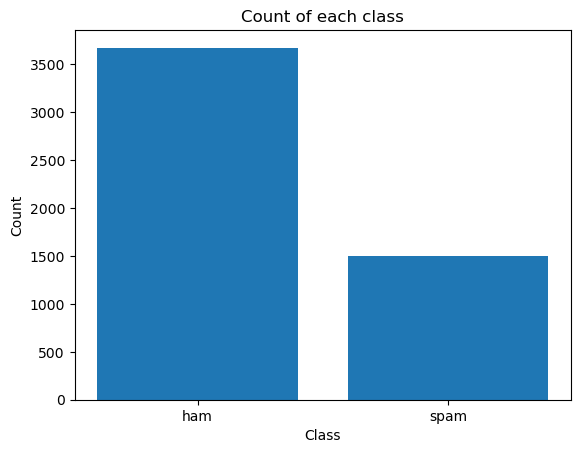

In [19]:
# Visualize class imbalance
class_counts = Counter(data["label"])
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Count of each class")
plt.show();

In [20]:
# Clean data: text to lowercase, remove uninformative words
data["text"] = data["text"].str.lower()
bad_words = ["the", "and", "is", "subject:"]
data["text"] = data["text"].apply(lambda x: ' '.join([word for word in x.split() if word not in bad_words]))

# Partition data into features and labels
x = data["text"]
y = data["label"]

# Vectorize data
vectorizer = CountVectorizer()
# Split data into train test split
x_transformed = vectorizer.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x_transformed, y, test_size=0.2)

In [21]:
# Init model, fit it to our train data set
multi_model = MultinomialNB()
multi_model.fit(x_train, y_train)

# Generate predictions on test data set
y_pred = multi_model.predict(x_test)

# Print success metrics eg accuracy, true positives, etc...
print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("True Positives:", cm[0, 0])
print("False Positives:", cm[0, 1])
print("True Negatives:", cm[1, 1])
print("False Negatives:", cm[1, 0])
print(classification_report(y_test, y_pred))

Accuracy: 0.9748792270531401
Confusion Matrix:
 [[708  12]
 [ 14 301]]
True Positives: 708
False Positives: 12
True Negatives: 301
False Negatives: 14
              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       720
        spam       0.96      0.96      0.96       315

    accuracy                           0.97      1035
   macro avg       0.97      0.97      0.97      1035
weighted avg       0.97      0.97      0.97      1035



In [22]:
fpr, tpr, threshs = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve");

ValueError: y_true takes value in {'ham', 'spam'} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.

In [ ]:
model = GaussianNB()
model.fit(x_train.toarray(), y_train)
y_pred = model.predict(x_test.toarray())
print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("True Positives:", cm[0, 0])
print("False Positives:", cm[0, 1])
print("True Negatives:", cm[1, 1])
print("False Negatives:", cm[1, 0])
print(classification_report(y_test, y_pred))